In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/application_train.csv')
print(f"Data Shape: {df.shape}")

Data Shape: (307511, 122)


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


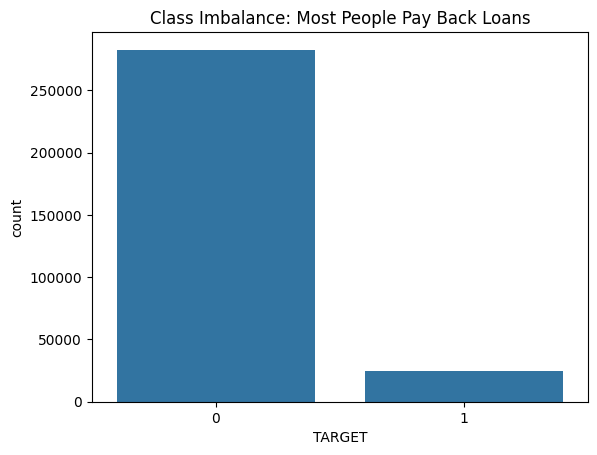

In [2]:
# Check class distribution
class_dist = df['TARGET'].value_counts(normalize=True)
print(class_dist)
# Result will likely be: 0 (Paid) = 92%, 1 (Default) = 8%

# Visualization
sns.countplot(x='TARGET', data=df)
plt.title("Class Imbalance: Most People Pay Back Loans")
plt.show()

In [3]:
# 1. Credit-to-Income Ratio (How much debt do they have relative to income?)
df['CREDIT_INCOME_PERCENT'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

# 2. Annuity-to-Income Ratio (How much of their monthly check goes to the loan?)
df['ANNUITY_INCOME_PERCENT'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# 3. Credit Term (Rough estimate of loan length in months)
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

In [4]:
# Simple strategy for MVP: Fill numbers with median, text with "Unknown"
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].median())

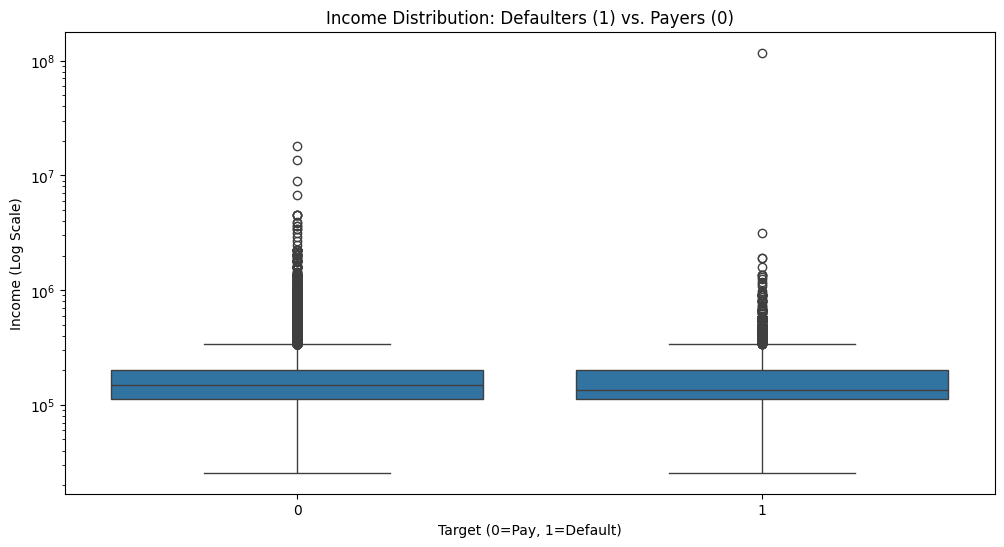

In [5]:
# Block: Income Distribution by Target
plt.figure(figsize=(12, 6))
# We use log scale because income usually has huge outliers
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)
plt.yscale('log') 
plt.title('Income Distribution: Defaulters (1) vs. Payers (0)')
plt.ylabel('Income (Log Scale)')
plt.xlabel('Target (0=Pay, 1=Default)')
plt.show()

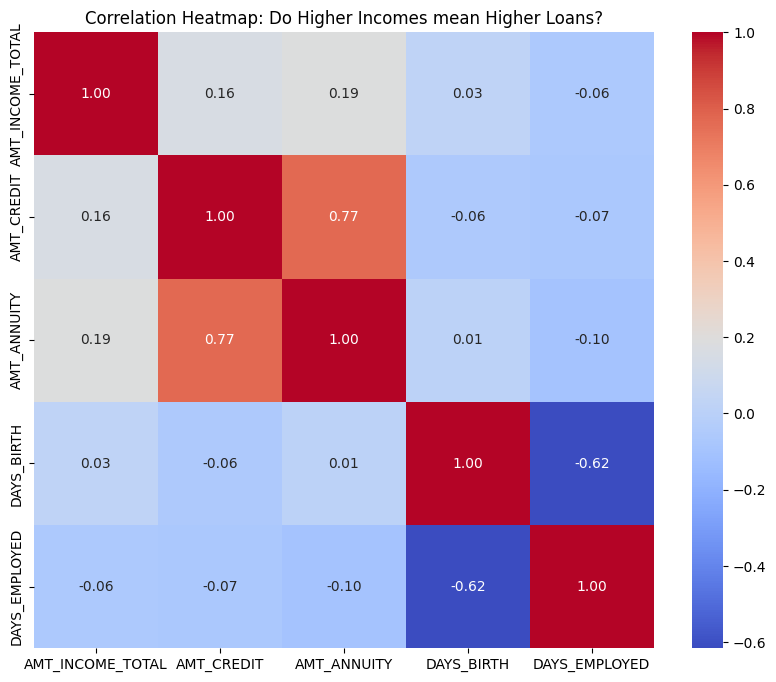

In [6]:
# Block: Correlation Matrix of Key Financial Features
cols_to_corr = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Do Higher Incomes mean Higher Loans?')
plt.show()

/var/folders/4h/stcdq6ts6210f3cxkvt176hc0000gn/T/ipykernel_42836/613977767.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=education_risk.index, y=education_risk.values, palette='viridis')


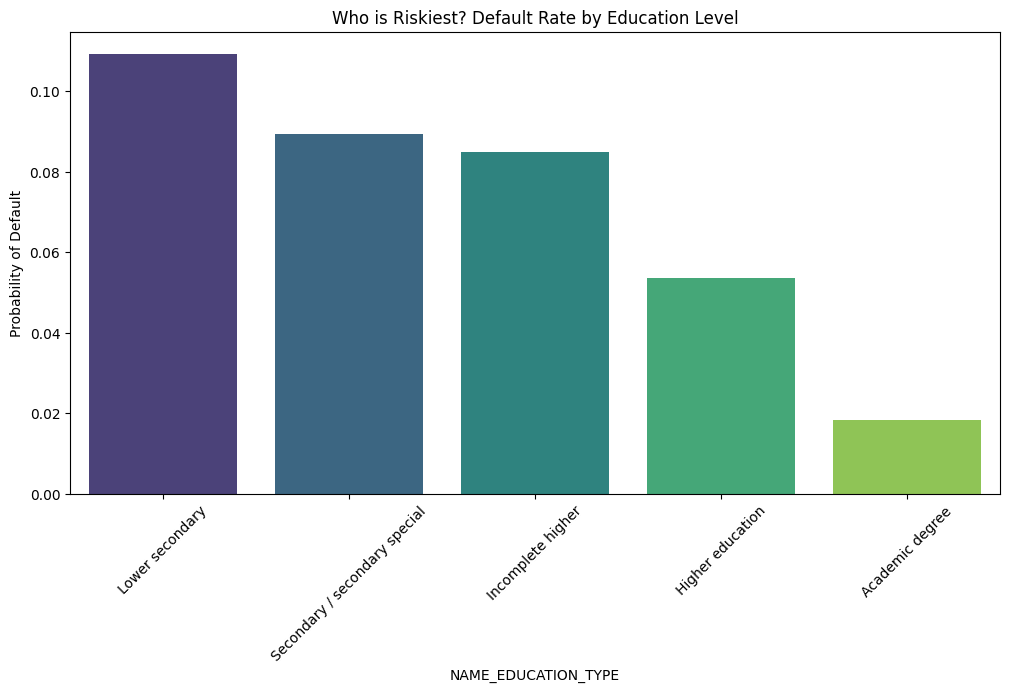

In [7]:
# Block: Default Rate by Education Type
# calculate the percentage of defaults per category
education_risk = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=education_risk.index, y=education_risk.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Who is Riskiest? Default Rate by Education Level')
plt.ylabel('Probability of Default')
plt.show()